Iniciando Benchmark...
Rodando Pandas...


/var/folders/rm/s36g6dxn0rvfklb433ww803c0000gn/T/ipykernel_2866/842757833.py:14: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/rm/s36g6dxn0rvfklb433ww803c0000gn/T/ipykernel_2866/842757833.py:14: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Rodando Polars...
Resultados - Tempo: Pandas (15.37s) vs Polars (2.73s)
Resultados - RAM: Pandas (1959MB) vs Polars (1799MB)


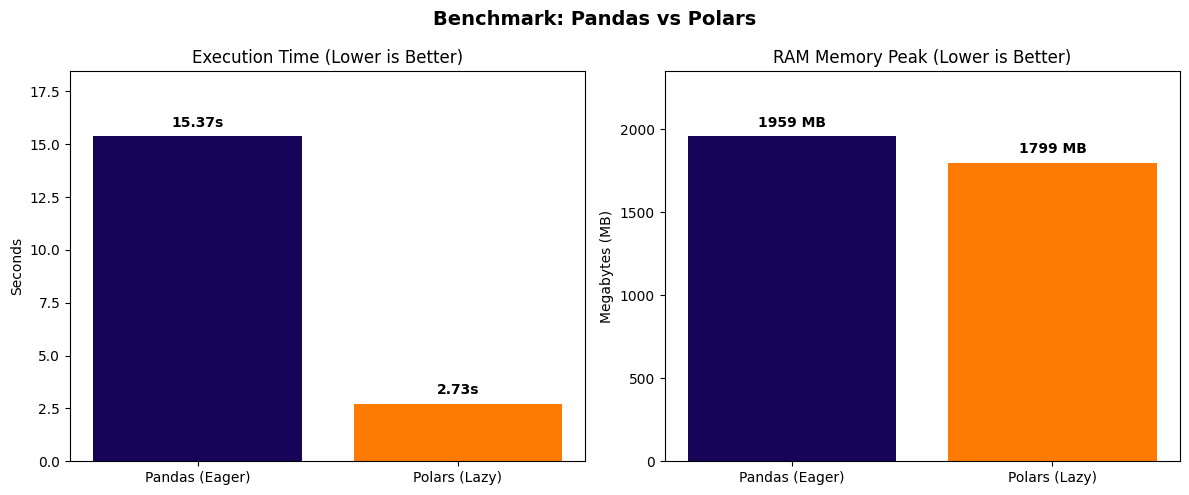

Benchmark concluído e gráfico 'benchmark_real_resultado.png' gerado com sucesso!


In [1]:
import pandas as pd
import polars as pl
import time
from memory_profiler import memory_usage
import matplotlib.pyplot as plt

# Configuração do Pandas
pd.set_option('display.max_columns', None)

def process_pandas(path: str):
    """
    Processamento usando Pandas (Eager)
    """
    df = pd.read_csv(path)
    grouped_df = (
        df.query("passenger_count > 1")
        .groupby(by="PULocationID")
        .agg({"fare_amount": "mean"})
        .sort_values(by="fare_amount", ascending=False)
        .reset_index() # Adicionado para igualar a estrutura do Polars
    )
    return grouped_df

def process_polars(path: str):
    """
    Processamento usando Polars (Lazy)
    """
    df = pl.scan_csv(path)
    df = df.filter(pl.col("passenger_count") > 1)
    grouped_df = (
        df.group_by("PULocationID")
        .agg(pl.col("fare_amount").mean())
        .sort(by="fare_amount", descending=True)
        .collect()
    )
    return grouped_df

path = 'data/test_data.csv'

print("Iniciando Benchmark...")

# --- Teste Pandas ---
print("Rodando Pandas...")
# Mede o tempo puro (sem o peso do profiler de memória)
start_time = time.time()
df_pd = process_pandas(path)
pandas_time = time.time() - start_time

# Mede o pico de memória (retorna o uso máximo em MB)
pandas_memory = memory_usage((process_pandas, (path,)), max_usage=True)

# --- Teste Polars ---
print("Rodando Polars...")
start_time = time.time()
df_pl = process_polars(path)
polars_time = time.time() - start_time

polars_memory = memory_usage((process_polars, (path,)), max_usage=True)

print(f"Resultados - Tempo: Pandas ({pandas_time:.2f}s) vs Polars ({polars_time:.2f}s)")
print(f"Resultados - RAM: Pandas ({pandas_memory:.0f}MB) vs Polars ({polars_memory:.0f}MB)")

labels = ['Pandas (Eager)', 'Polars (Lazy)']
times = [pandas_time, polars_time]
memories = [pandas_memory, polars_memory]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cores = ['#150458', '#FF7A00']

# Gráfico de Tempo
bars1 = ax1.bar(labels, times, color=cores)
ax1.set_title('Execution Time (Lower is Better)', fontsize=12)
ax1.set_ylabel('Seconds')
ax1.set_ylim(0, max(times) * 1.2)

for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (max(times)*0.02),
             f'{yval:.2f}s', ha='center', va='bottom', fontweight='bold')

# Gráfico de Memória
bars2 = ax2.bar(labels, memories, color=cores)
ax2.set_title('RAM Memory Peak (Lower is Better)', fontsize=12)
ax2.set_ylabel('Megabytes (MB)')
ax2.set_ylim(0, max(memories) * 1.2)

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (max(memories)*0.02),
             f'{yval:.0f} MB', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Benchmark: Pandas vs Polars', fontsize=14, fontweight='bold')
plt.tight_layout()

# Salva e exibe no Jupyter
plt.savefig('benchmark_real_resultado.png', dpi=300)
plt.show()

print("Benchmark concluído e gráfico 'benchmark_real_resultado.png' gerado com sucesso!")